# Tidy Data
## Load and Inspect Data

In [7]:
import os
import pandas as pd

base_dir = os.getcwd()
data_dir = os.path.join(base_dir, 'Ausgrid_solar_home_data')

csv_filepath_1 = os.path.join(data_dir, 'Solar home 2010-2011.csv')
csv_filepath_2 = os.path.join(data_dir, 'Solar home 2011-2012.csv')
csv_filepath_3 = os.path.join(data_dir, 'Solar home 2012-2013.csv')

# Load the three yearly files
df_2010 = pd.read_csv(csv_filepath_1, skiprows=1)
df_2011 = pd.read_csv(csv_filepath_2, skiprows=1)
df_2012 = pd.read_csv(csv_filepath_3, skiprows=1)

# Inspect each file
for name, df in [('2010-2011', df_2010), ('2011-2012', df_2011), ('2012-2013', df_2012)]:
    print(f"Name: {name}")
    print(f"Shape: {df.shape}")
    print(f"Columns:", df.columns.tolist())
    print(f"Missing values: {df.isna().sum().sum()}\n")

Name: 2010-2011
Shape: (269735, 53)
Columns: ['Customer', 'Generator Capacity', 'Postcode', 'Consumption Category', 'date', '0:30', '1:00', '1:30', '2:00', '2:30', '3:00', '3:30', '4:00', '4:30', '5:00', '5:30', '6:00', '6:30', '7:00', '7:30', '8:00', '8:30', '9:00', '9:30', '10:00', '10:30', '11:00', '11:30', '12:00', '12:30', '13:00', '13:30', '14:00', '14:30', '15:00', '15:30', '16:00', '16:30', '17:00', '17:30', '18:00', '18:30', '19:00', '19:30', '20:00', '20:30', '21:00', '21:30', '22:00', '22:30', '23:00', '23:30', '0:00']
Missing values: 0

Name: 2011-2012
Shape: (270304, 54)
Columns: ['Customer', 'Generator Capacity', 'Postcode', 'Consumption Category', 'date', '0:30', '1:00', '1:30', '2:00', '2:30', '3:00', '3:30', '4:00', '4:30', '5:00', '5:30', '6:00', '6:30', '7:00', '7:30', '8:00', '8:30', '9:00', '9:30', '10:00', '10:30', '11:00', '11:30', '12:00', '12:30', '13:00', '13:30', '14:00', '14:30', '15:00', '15:30', '16:00', '16:30', '17:00', '17:30', '18:00', '18:30', '19:00'

The documentation says `Row Quality` distinguishes actual (blank) readings from non-actual (NA) readings where some or all half-hour values were estimated or substituted. Let's check to see if the missing values are coming from the `Row Quality` column. 

In [8]:
print(df_2011["Row Quality"].value_counts(dropna=False))
print(df_2012["Row Quality"].value_counts(dropna=False))

Row Quality
NaN    270304
Name: count, dtype: int64
Row Quality
NaN    268557
Name: count, dtype: int64


The only value is NaN, so we can drop the column and proceed.
## Combine all three year tables

In [12]:
df_2011 = df_2011.drop(columns=["Row Quality"], errors="ignore")
df_2012 = df_2012.drop(columns=["Row Quality"], errors="ignore")
df = pd.concat([df_2010, df_2011, df_2012], ignore_index=True)

# Inspect table
print(f"Name: Combined 2010-2013")
print(f"Shape: {df.shape}")
print(f"Columns:", df.columns.tolist())
print(f"Missing values: {df.isna().sum().sum()}\n")

Name: Combined 2010-2013
Shape: (808596, 53)
Columns: ['Customer', 'Generator Capacity', 'Postcode', 'Consumption Category', 'date', '0:30', '1:00', '1:30', '2:00', '2:30', '3:00', '3:30', '4:00', '4:30', '5:00', '5:30', '6:00', '6:30', '7:00', '7:30', '8:00', '8:30', '9:00', '9:30', '10:00', '10:30', '11:00', '11:30', '12:00', '12:30', '13:00', '13:30', '14:00', '14:30', '15:00', '15:30', '16:00', '16:30', '17:00', '17:30', '18:00', '18:30', '19:00', '19:30', '20:00', '20:30', '21:00', '21:30', '22:00', '22:30', '23:00', '23:30', '0:00']
Missing values: 0



## Reformat and Tidy Data
Convert wide format to tidy long format. Replace `date` and `time` columns with proper datetime column. The `date` column is inconsistently formatted, so we use `format="mixed"` to handle multiple forms such as `1-Jul-10` and `1/07/2011`.

In [20]:
# Half-hour columns
time_cols = df.columns[5:]

df_long = df.melt(
    id_vars=df.columns[:5],
    value_vars=time_cols,
    var_name='time',
    value_name='kWh')

# Create timestamp
df_long['datetime'] = pd.to_datetime(
    df_long['date'].astype(str) + " " + df_long["time"],
    format="mixed",
    dayfirst=True)

# Drop redundant date and time columns
df_long = df_long.drop(columns=["date", "time"])

# Optional: sort
df_long = df_long.sort_values(['Customer', 'Consumption Category', 'datetime']).reset_index(drop=True)

# Optional: change column order
df_long = df_long[[
    "Customer", "Generator Capacity", "Postcode",
    "Consumption Category", "datetime", "kWh"]]

# Inspect table
display(df_long.head())
print(f"Shape: {df_long.shape}")
print(f"Columns:", df_long.columns.tolist())
print(f"Missing values: {df_long.isna().sum().sum()}\n")

,Customer,Generator Capacity,Postcode,Consumption Category,datetime,kWh
0,1,3.78,2076,CL,2010-07-01 00:00:00,1.075
1,1,3.78,2076,CL,2010-07-01 00:30:00,1.250
2,1,3.78,2076,CL,2010-07-01 01:00:00,1.244
3,1,3.78,2076,CL,2010-07-01 01:30:00,1.256
4,1,3.78,2076,CL,2010-07-01 02:00:00,0.744


Shape: (38812608, 6)
Columns: ['Customer', 'Generator Capacity', 'Postcode', 'Consumption Category', 'datetime', 'kWh']
Missing values: 0



# Analyze Data
## Customer-level solar statistics
`kWp` means kilowatt-peak: the rated maximum power capacity of the solar panels under standard test conditions. The units are different because kWp is power capacity, while kWh is energy produced over time. Dividing them gives an energy-per-unit-capacity measure, which is useful for comparing differently sized solar systems. The Ausgrid documentation itself reports annual gross generation in `kWh/kWp`.
$$
\frac{\text{kWh}}{\text{kWp}} =
\frac{\text{energy generated (kWh)}}{\text{rated capacity (kWp)}}
$$

In [28]:
# Customer-level solar statistics
solar_stats = (
    df_long[df_long['Consumption Category'] == 'GG']
    .groupby('Customer')
    .agg(
        generator_capacity_kwp=('Generator Capacity', 'first'),
        annual_pv_kwh=('kWh','sum'))
    .reset_index())

# PV generation normalized by system capacity
solar_stats['pv_kwh_per_kwp'] = (
    solar_stats['annual_pv_kwh'] / solar_stats['generator_capacity_kwp'])

display(solar_stats.head().style.hide(axis="index"))
print(solar_stats.drop(columns="Customer").describe().drop(index="count"))

Customer,generator_capacity_kwp,annual_pv_kwh,pv_kwh_per_kwp
1,3.780000,14708.534000,3891.146561
2,1.620000,5995.505000,3700.929012
3,1.000000,4419.744000,4419.744000
4,1.000000,3802.059000,3802.059000
5,1.000000,3658.742000,3658.742000


      generator_capacity_kwp  annual_pv_kwh  pv_kwh_per_kwp
mean                1.683300    6382.756697     3779.737463
std                 1.036846    4177.495487      497.604430
min                 1.000000    1927.716000     1752.469091
25%                 1.020000    3953.146500     3464.586750
50%                 1.500000    5312.645000     3826.478810
75%                 2.000000    7002.282500     4145.007850
max                 9.990000   43091.895000     4870.287143


The mean system size is `1.68 kWp` and the median is `1.50 kWp`, matching Ausgrid's documentation almost exactly. The `annual_pv_kwh` is actually a 3-year total because we combined all three years before summing. The mean of `6382.8 kWh` corresponds to about `2128 kWh/year`, which is close to Ausgrid's reported annual means of `2119`, `2083`, and `2181 kWh`. Likewise, `3779 kWh/kWp` over 3 years is about `1260 kWh/kwp` per year, close to the documented valued `(~1231-1297)`. There is substantual variation between customers: system size ranges from 1 to 9.99 kWp, and normalized annual generation varies considerably.

## Daily and Seasonal Patterns 

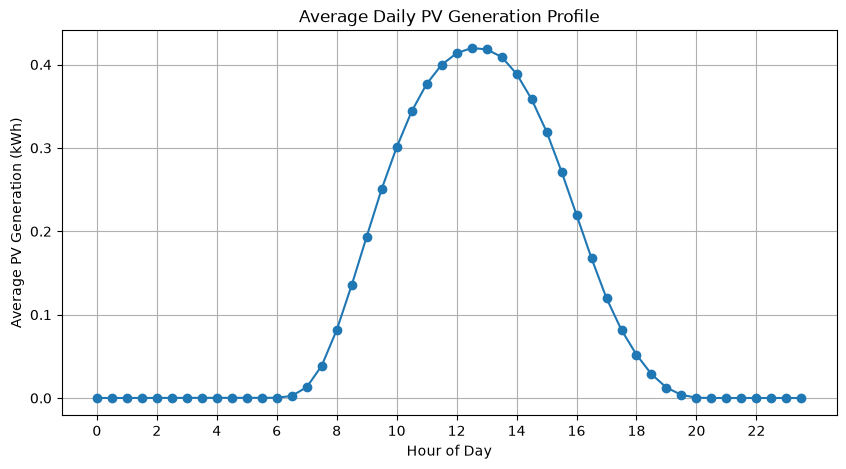

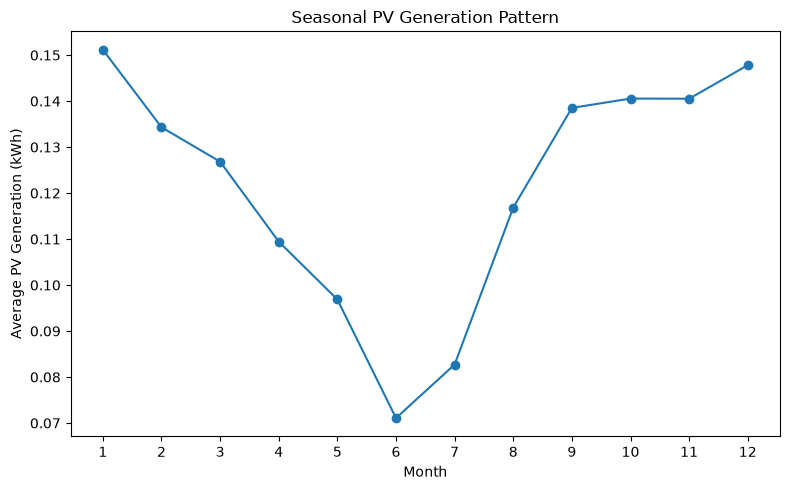

In [39]:
import matplotlib.pyplot as plt

# PV data
pv = df_long[df_long["Consumption Category"] == "GG"].copy()

# Numeric hour of day
pv['hour'] = pv['datetime'].dt.hour + pv['datetime'].dt.minute / 60

# Daily pattern: average PV generation by half-hour
daily_profile = pv.groupby(pv['hour'])["kWh"].mean()

plt.figure(figsize=(10,5))
plt.plot(daily_profile.index, daily_profile.values, marker='o')
plt.xlabel("Hour of Day")
plt.ylabel("Average PV Generation (kWh)")
plt.title("Average Daily PV Generation Profile")
plt.xticks(range(0, 24, 2))
plt.grid()
plt.show()

# Seasonal pattern: average PV generation by month
seasonal_profile = pv.groupby(pv['datetime'].dt.month)['kWh'].mean()

plt.figure(figsize=(8, 5))
plt.plot(seasonal_profile.index, seasonal_profile.values, marker="o")
plt.xlabel("Month")
plt.ylabel("Average PV Generation (kWh)")
plt.title("Seasonal PV Generation Pattern")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

In [ ]:
### Daily Profile with Percentile Bands

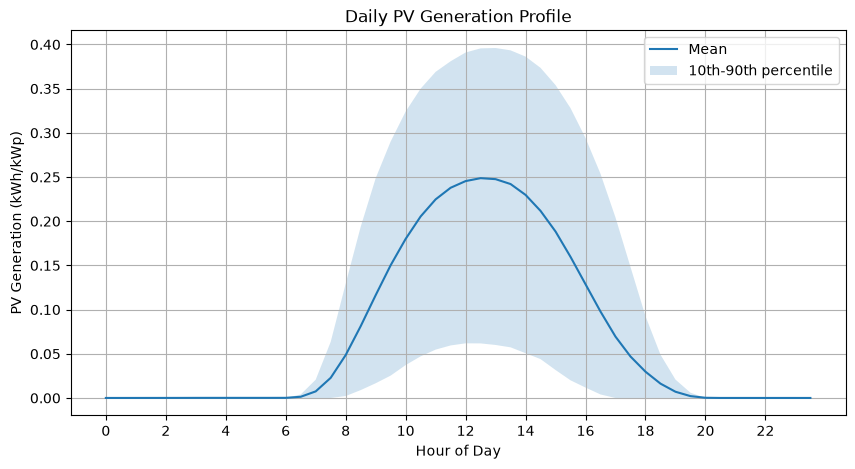

In [38]:
import matplotlib.pyplot as plt

pv = df_long[df_long['Consumption Category'] == 'GG'].copy()

pv["hour"] = pv["datetime"].dt.hour + pv["datetime"].dt.minute / 60
pv["pv_per_kwp"] = pv["kWh"] / pv["Generator Capacity"]

profile = (
    pv.groupby('hour')['pv_per_kwp']
    .agg(
        mean='mean',
        p10=lambda x: x.quantile(0.10),
        p90=lambda x: x.quantile(0.90)))

plt.figure(figsize=(10,5))
plt.plot(profile.index, profile['mean'], label='Mean')
plt.fill_between(
    profile.index,
    profile['p10'],
    profile['p90'],
    alpha=0.2,
    label='10th-90th percentile')
plt.xlabel('Hour of Day')
plt.ylabel("PV Generation (kWh/kWp)")
plt.title("Daily PV Generation Profile")
plt.xticks(range(0, 24, 2))
plt.legend()
plt.grid()
plt.show()

What population does the shaded plot represent? Each point is calculated from all GG observations at that house, pooled across all 300 customers, all three years, and all days. This represents combined customer-to-customer and day-to-day variability. 
Why is its shape so different from the previous plot? Normalization by system capacity can change the average because the first plot wights larger PV systems more heavily, wheras `kWh/kWp` gives each customer roughly equal weight. 

## Day-to-day variability

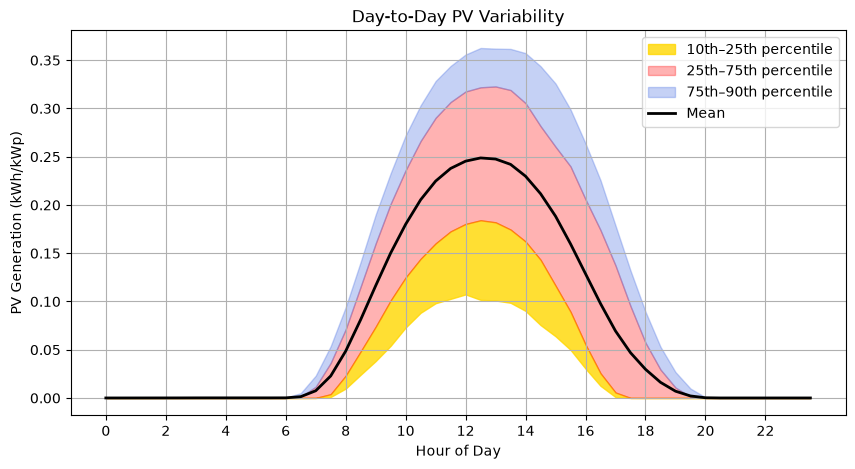

In [49]:
# Daily profiles: average across customers for each day
pv["day"] = pv["datetime"].dt.date
pv["pv_per_kwp"] = pv["kWh"] / pv["Generator Capacity"]
daily = pv.groupby(['day', 'hour'])['pv_per_kwp'].mean()

day_profile = daily.groupby("hour").agg(
    mean="mean",
    p10=lambda x: x.quantile(0.10),
    p25=lambda x: x.quantile(0.25),
    p75=lambda x: x.quantile(0.75),
    p90=lambda x: x.quantile(0.90)
)

plt.figure(figsize=(10, 5))

plt.fill_between(day_profile.index, day_profile["p10"], day_profile["p25"],
                 color="gold", alpha=0.8, label="10th–25th percentile")
plt.fill_between(day_profile.index, day_profile["p25"], day_profile["p75"],
                 color="red", alpha=0.3, label="25th–75th percentile")
plt.fill_between(day_profile.index, day_profile["p75"], day_profile["p90"],
                 color="royalblue", alpha=0.3, label="75th–90th percentile")

plt.plot(day_profile.index, day_profile["mean"],
         color="black", linewidth=2, label="Mean")

plt.xlabel("Hour of Day")
plt.ylabel("PV Generation (kWh/kWp)")
plt.title("Day-to-Day PV Variability")
plt.xticks(range(0, 24, 2))
plt.legend()
plt.grid()
plt.show()

### Day-to-day Variability Table

In [53]:
# Day-to-day variability table
daily = pv.groupby(["day", "hour"])["pv_per_kwp"].mean().reset_index()
day_variability = daily.groupby("hour")["pv_per_kwp"].agg(
    mean="mean",
    std="std",
    p10=lambda x: x.quantile(0.10),
    p25=lambda x: x.quantile(0.25),
    median="median",
    p75=lambda x: x.quantile(0.75),
    p90=lambda x: x.quantile(0.90))

day_variability["IQR"] = (
    day_variability["p75"] - day_variability["p25"])

day_variability["CV"] = (
    day_variability["std"] / day_variability["mean"])

display(day_variability.round(3))

,mean,std,p10,p25,median,p75,p90,IQR,CV
hour,,,,,,,,,
0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.612
0.5,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.947
1.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.393
1.5,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.822
2.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,2.046
2.5,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,2.252
3.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,2.617
3.5,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,2.644
4.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,2.704


## Customer-to-Customer Variability

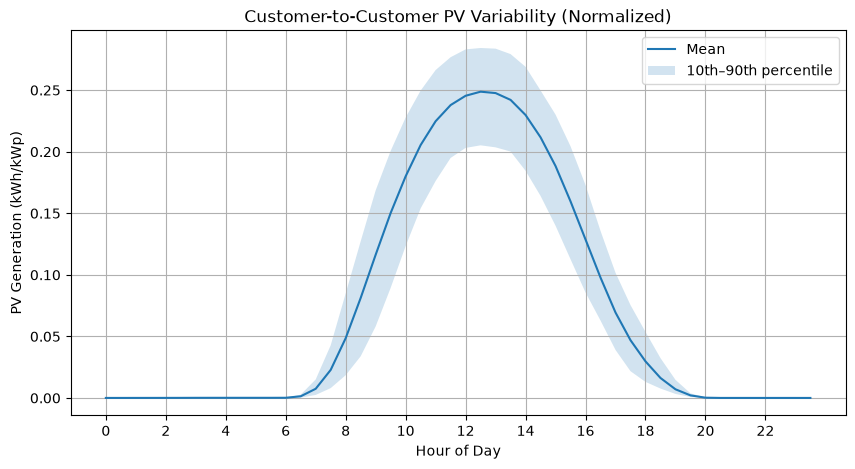

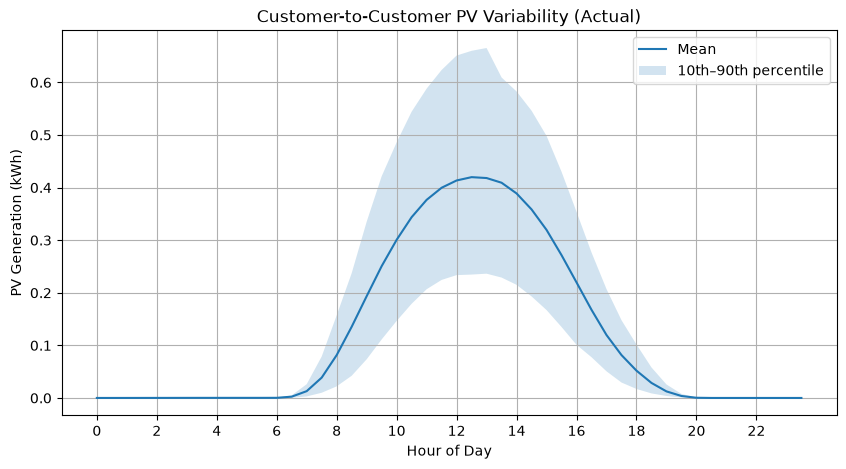

In [43]:
# Customer profiles: average across all days for each customer
customer_kwh = pv.groupby(["Customer", "hour"])["kWh"].mean()
customer_kwp = pv.groupby(["Customer", "hour"])["pv_per_kwp"].mean()

# Aggregate across customers
kwh_profile = customer_kwh.groupby("hour").agg(
    mean="mean",
    p10=lambda x: x.quantile(0.10),
    p90=lambda x: x.quantile(0.90)
)

kwp_profile = customer_kwp.groupby("hour").agg(
    mean="mean",
    p10=lambda x: x.quantile(0.10),
    p90=lambda x: x.quantile(0.90)
)

# Normalized
plt.figure(figsize=(10, 5))
plt.plot(kwp_profile.index, kwp_profile["mean"], label="Mean")
plt.fill_between(kwp_profile.index, kwp_profile["p10"], kwp_profile["p90"],
                 alpha=0.2, label="10th–90th percentile")
plt.xlabel("Hour of Day")
plt.ylabel("PV Generation (kWh/kWp)")
plt.title("Customer-to-Customer PV Variability (Normalized)")
plt.xticks(range(0, 24, 2))
plt.legend()
plt.grid()
plt.show()

# Un-normalized
plt.figure(figsize=(10, 5))
plt.plot(kwh_profile.index, kwh_profile["mean"], label="Mean")
plt.fill_between(kwh_profile.index, kwh_profile["p10"], kwh_profile["p90"],
                 alpha=0.2, label="10th–90th percentile")
plt.xlabel("Hour of Day")
plt.ylabel("PV Generation (kWh)")
plt.title("Customer-to-Customer PV Variability (Actual)")
plt.xticks(range(0, 24, 2))
plt.legend()
plt.grid()
plt.show()

In [54]:
# Customer-to-customer variability
customer = pv.groupby(["Customer", "hour"])["pv_per_kwp"].mean().reset_index()

customer_variability = customer.groupby("hour")["pv_per_kwp"].agg(
    mean="mean",
    std="std",
    p10=lambda x: x.quantile(0.10),
    p25=lambda x: x.quantile(0.25),
    median="median",
    p75=lambda x: x.quantile(0.75),
    p90=lambda x: x.quantile(0.90)
)

customer_variability["IQR"] = (
    customer_variability["p75"] - customer_variability["p25"]
)

customer_variability["CV"] = (
    customer_variability["std"] / customer_variability["mean"]
)

display(customer_variability.round(3))

,mean,std,p10,p25,median,p75,p90,IQR,CV
hour,,,,,,,,,
0.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.410
0.5,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,2.802
1.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,4.746
1.5,0.000,0.001,0.000,0.000,0.000,0.000,0.000,0.000,6.844
2.0,0.000,0.001,0.000,0.000,0.000,0.000,0.000,0.000,7.792
2.5,0.000,0.001,0.000,0.000,0.000,0.000,0.000,0.000,8.274
3.0,0.000,0.001,0.000,0.000,0.000,0.000,0.000,0.000,8.764
3.5,0.000,0.001,0.000,0.000,0.000,0.000,0.000,0.000,8.893
4.0,0.000,0.001,0.000,0.000,0.000,0.000,0.000,0.000,9.118
